# DGNet — ModelNet10 Original — Setup + Prétraitement (notebook fusionné)

Fusion de `00-dgnet-modelnet10-project-setup` et `01-dgnet-modelnet10-original-preprocessing`
en un seul notebook, avec correction du bug d'isolation Jittor et ajout du diagnostic
topologique NetworkX.

## Étapes
1. Clonage du projet depuis GitHub (avec le sous-module DGNet officiel)
2. Connexion du dataset ModelNet10 (symlink)
3. Validation du projet et du dataset
4. Environnement Python isolé pour Jittor (venv)
5. Test de simplification géométrique (noyau principal, trimesh)
6. Construction de la pyramide DGNet (dans le venv isolé, via subprocess)
7. Diagnostic topologique NetworkX (desk / night_stand / sofa)


In [1]:
from pathlib import Path

WORKING_ROOT = Path("/kaggle/working")
PROJECT_NAME = "3d-mesh-augmentation-study"
PROJECT_ROOT = WORKING_ROOT / PROJECT_NAME

GITHUB_URL = "https://github.com/Bilal51002/3d-mesh-augmentation-study.git"
GITHUB_BRANCH = "feat/dgnet-modelnet10-preprocessing"

EXPECTED_PROJECT_COMMIT = "92b5e8a"
EXPECTED_DGNET_COMMIT = "70abf402b58f7d44f0765c0436bfb03b53af4a5d"

EXPECTED_CLASSES = [
    "bathtub", "bed", "chair", "desk", "dresser",
    "monitor", "night_stand", "sofa", "table", "toilet",
]

EXPECTED_TRAIN_COUNT = 3991
EXPECTED_TEST_COUNT = 908
EXPECTED_TOTAL_COUNT = 4899

TARGET_FACE_COUNT = 1024
PYRAMID_LEVELS = 6

print("Project root :", PROJECT_ROOT)
print("Target faces :", TARGET_FACE_COUNT)


Project root : /kaggle/working/3d-mesh-augmentation-study
Target faces : 1024


## 1. Clonage du projet depuis GitHub

In [2]:
import os
import shutil
import subprocess

# Se replacer dans /kaggle/working AVANT toute suppression, pour ne jamais
# supprimer le repertoire dans lequel le kernel est physiquement positionne
# (sinon subprocess.run echoue avec "Unable to read current working directory").
os.chdir(WORKING_ROOT)

if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)

subprocess.run(
    [
        "git", "clone", "--recurse-submodules",
        "--branch", GITHUB_BRANCH,
        GITHUB_URL, str(PROJECT_ROOT),
    ],
    cwd=str(WORKING_ROOT),
    check=True,
)

print("✅ Projet cloné :", PROJECT_ROOT)


Cloning into '/kaggle/working/3d-mesh-augmentation-study'...
Submodule 'models/dgnet' (https://github.com/li-xl/DGNet.git) registered for path 'models/dgnet'
Cloning into '/kaggle/working/3d-mesh-augmentation-study/models/dgnet'...


Submodule path 'models/dgnet': checked out '70abf402b58f7d44f0765c0436bfb03b53af4a5d'
✅ Projet cloné : /kaggle/working/3d-mesh-augmentation-study


In [3]:
%cd /kaggle/working/3d-mesh-augmentation-study


/kaggle/working/3d-mesh-augmentation-study


In [4]:
!git branch --show-current
!git log -1 --oneline
!git submodule status


feat/dgnet-modelnet10-preprocessing
92b5e8a (HEAD -> feat/dgnet-modelnet10-preprocessing, origin/feat/dgnet-modelnet10-preprocessing) chore(dgnet): prepare ModelNet10 workflow for Kaggle
 70abf402b58f7d44f0765c0436bfb03b53af4a5d models/dgnet (heads/master)


## 2. Connexion du dataset ModelNet10 (symlink)

In [5]:
import os

KAGGLE_DATASET_ROOT = Path(
    "/kaggle/input/datasets/bilalbilalkh/"
    "3d-mesh-study-modelnet10-original/ModelNet10"
)

DATASET_ROOT = PROJECT_ROOT / "datasets" / "modelnet10" / "original"

DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)

if DATASET_ROOT.is_symlink():
    DATASET_ROOT.unlink()
elif DATASET_ROOT.exists():
    if DATASET_ROOT.is_dir():
        shutil.rmtree(DATASET_ROOT)
    else:
        DATASET_ROOT.unlink()

os.symlink(KAGGLE_DATASET_ROOT, DATASET_ROOT, target_is_directory=True)

print("✅ Lien ModelNet10 créé")
print("Chemin projet :", DATASET_ROOT)
print("Source réelle :", DATASET_ROOT.resolve())


✅ Lien ModelNet10 créé
Chemin projet : /kaggle/working/3d-mesh-augmentation-study/datasets/modelnet10/original
Source réelle : /kaggle/input/datasets/bilalbilalkh/3d-mesh-study-modelnet10-original/ModelNet10


## 3. Validation du projet et du dataset

In [6]:
required_files = [
    PROJECT_ROOT / "adapters/dgnet/face_pool_compat.py",
    PROJECT_ROOT / "scripts/dgnet/create_manifests.py",
    PROJECT_ROOT / "scripts/dgnet/validate_manifests.py",
    PROJECT_ROOT / "scripts/dgnet/audit_modelnet10_meshes.py",
    PROJECT_ROOT / "scripts/dgnet/summarize_modelnet10_audit.py",
    PROJECT_ROOT / "scripts/dgnet/test_modelnet10_pyramid.py",
    PROJECT_ROOT / "scripts/dgnet/validate_modelnet10_classes.py",
    PROJECT_ROOT / "models/dgnet/jmesh/layers/face_pool.py",
]

missing_files = [p for p in required_files if not p.is_file()]

for path in required_files:
    status = "OK" if path.is_file() else "MANQUANT"
    print(f"{status:8} {path.relative_to(PROJECT_ROOT)}")

if missing_files:
    raise FileNotFoundError(f"Fichiers manquants : {missing_files}")

print("\n✅ Le code DGNet est complet.")


OK       adapters/dgnet/face_pool_compat.py
OK       scripts/dgnet/create_manifests.py
OK       scripts/dgnet/validate_manifests.py
OK       scripts/dgnet/audit_modelnet10_meshes.py
OK       scripts/dgnet/summarize_modelnet10_audit.py
OK       scripts/dgnet/test_modelnet10_pyramid.py
OK       scripts/dgnet/validate_modelnet10_classes.py
OK       models/dgnet/jmesh/layers/face_pool.py

✅ Le code DGNet est complet.


In [7]:
class_names = sorted(
    p.name for p in DATASET_ROOT.iterdir()
    if p.is_dir() and p.name in EXPECTED_CLASSES
)

train_files = list(DATASET_ROOT.glob("*/train/*.off"))
test_files = list(DATASET_ROOT.glob("*/test/*.off"))
all_dataset_files = list(DATASET_ROOT.rglob("*.off"))

print("Classes :", len(class_names))
print("Train   :", len(train_files))
print("Test    :", len(test_files))
print("Total   :", len(all_dataset_files))

assert class_names == EXPECTED_CLASSES
assert len(train_files) == EXPECTED_TRAIN_COUNT
assert len(test_files) == EXPECTED_TEST_COUNT
assert len(all_dataset_files) == EXPECTED_TOTAL_COUNT

print("\n✅ ModelNet10 est valide.")


Classes : 10
Train   : 3991
Test    : 908
Total   : 4899

✅ ModelNet10 est valide.


## 4. Environnement Python isolé pour Jittor

Jittor est installé **uniquement** dans ce venv, jamais dans le noyau principal Kaggle,
pour éviter le conflit NumPy 2.x (noyau principal) / NumPy 1.26.4 (Jittor).

In [8]:
import sys

VENV_ROOT = WORKING_ROOT / "dgnet-jittor-env"
VENV_PYTHON = VENV_ROOT / "bin" / "python"
READY_MARKER = VENV_ROOT / ".dgnet_environment_ready"

REQUIRED_PACKAGES = [
    "numpy==1.26.4",
    "trimesh==4.12.2",
    "fast-simplification==0.1.13",
    "jittor==1.3.11.0",
    "tensorboardX==2.6.4",
    "plyfile",
    "pyyaml",
    "tqdm",
    "scipy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "psutil",
    "networkx",
    "open3d",
    "wrapt",
]

os.chdir(WORKING_ROOT)

# Jittor 1.3.11.0 crashes on Python >= 3.11 (confirmed in its source code:
# py_var_tracer.cc checks PY_MINOR_VERSION>=11 and aborts). Use Python 3.10
# for the isolated venv instead of the main kernel's Python 3.12.
python310_path = shutil.which("python3.10")
if python310_path is None:
    print("Python 3.10 introuvable, installation via apt...")
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "python3.10", "python3.10-venv", "python3.10-distutils", "python3.10-dev"],
        check=True,
    )
    python310_path = shutil.which("python3.10")

if python310_path is None:
    raise RuntimeError("Impossible d'installer Python 3.10.")

print("Python 3.10 trouve :", python310_path)

environment_ready = VENV_PYTHON.is_file() and READY_MARKER.is_file()

if not environment_ready:
    if VENV_ROOT.exists():
        shutil.rmtree(VENV_ROOT)

    print("1. Installation de virtualenv...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "virtualenv"],
        cwd=WORKING_ROOT, check=True,
    )

    print("2. Création de l'environnement isolé (Python 3.10)...")
    subprocess.run(
        [sys.executable, "-m", "virtualenv", "--clear", "--python", python310_path, str(VENV_ROOT)],
        cwd=WORKING_ROOT, check=True,
    )

    if not VENV_PYTHON.is_file():
        raise FileNotFoundError(f"Python isolé introuvable : {VENV_PYTHON}")

    print("3. Installation des dépendances DGNet...")
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir",
         "--upgrade", "pip", "setuptools", "wheel"],
        cwd=WORKING_ROOT, check=True,
    )
    subprocess.run(
        [str(VENV_PYTHON), "-m", "pip", "install", "--quiet", "--no-cache-dir", *REQUIRED_PACKAGES],
        cwd=WORKING_ROOT, check=True,
    )

    READY_MARKER.write_text("DGNet environment ready.\n", encoding="utf-8")
else:
    print("L'environnement isolé existe déjà. Installation ignorée.")

if not VENV_PYTHON.is_file():
    raise FileNotFoundError(f"Interpréteur introuvable : {VENV_PYTHON}")

print("\n✅ Environnement isolé prêt (Python 3.10)")
print("Python :", VENV_PYTHON)

Python 3.10 trouve : /usr/bin/python3.10
1. Installation de virtualenv...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 33.9 MB/s eta 0:00:00
2. Création de l'environnement isolé (Python 3.10)...
created virtual environment CPython3.10.12.final.0-64-x86_64 in 885ms
  creator CPython3Posix(dest=/kaggle/working/dgnet-jittor-env, clear=True, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1, setuptools==84.0.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator
3. Installation des dépendances DGNet...

✅ Environnement isolé prêt (Python 3.10)
Python : /kaggle/working/dgnet-jittor-env/bin/python


In [9]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)


def run_in_venv(args, **kwargs):
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)

In [10]:
import importlib
import platform

modules_to_check = {
    "NumPy": "numpy", "SciPy": "scipy", "Pandas": "pandas",
    "Scikit-learn": "sklearn", "Trimesh": "trimesh",
    "TensorBoardX": "tensorboardX", "Jittor": "jittor",
    "Plyfile": "plyfile", "PyYAML": "yaml", "TQDM": "tqdm",
}

print("Environnement Python (noyau principal)")
print("Python   :", sys.version)
print("Platform :", platform.platform())
print()
for display_name, import_name in modules_to_check.items():
    try:
        module = importlib.import_module(import_name)
        version = getattr(module, "__version__", "version non exposée")
        print(f"{display_name:<16} ✅ {version}")
    except Exception as error:
        print(f"{display_name:<16} ❌ {type(error).__name__}: {error}")


Environnement Python (noyau principal)
Python   : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform : Linux-6.12.90+-x86_64-with-glibc2.35

NumPy            ✅ 2.0.2
SciPy            ✅ 1.16.3
Pandas           ✅ 2.3.3
Scikit-learn     ✅ 1.6.1
Trimesh          ❌ ModuleNotFoundError: No module named 'trimesh'
TensorBoardX     ❌ ModuleNotFoundError: No module named 'tensorboardX'
Jittor           ❌ ModuleNotFoundError: No module named 'jittor'
Plyfile          ❌ ModuleNotFoundError: No module named 'plyfile'
PyYAML           ✅ 6.0.3
TQDM             ✅ 4.67.3


In [11]:
completed = subprocess.run(
    [str(VENV_PYTHON), "-c", "import site; print(site.getsitepackages()[0])"],
    capture_output=True, text=True, check=True,
)
VENV_SITE_PACKAGES = completed.stdout.strip()

VENV_ENV = os.environ.copy()
VENV_ENV["PYTHONPATH"] = VENV_SITE_PACKAGES
VENV_ENV.pop("PYTHONSTARTUP", None)


def run_in_venv(args, **kwargs):
    """Lance VENV_PYTHON avec -S (ignore site/sitecustomize) et un
    PYTHONPATH explicite vers le site-packages du venv, pour eviter que
    le sitecustomize.py bruyant de Kaggle ne corrompe le cache Jittor."""
    full_args = [str(VENV_PYTHON), "-S"] + list(args)
    kwargs.setdefault("env", VENV_ENV)
    kwargs.setdefault("cwd", WORKING_ROOT)
    return subprocess.run(full_args, **kwargs)


# Verification
check = run_in_venv(["-c", "import trimesh, jittor; print('OK', trimesh.__version__)"],
                     capture_output=True, text=True)
print("STDOUT:", check.stdout)
print("STDERR:", check.stderr[-1000:] if check.stderr else "")

STDOUT: [i 0827 10:42:40.710309 24 lock.py:85] Create lock file:/root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/jittor.lock
[i 0827 10:42:40.722741 24 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 10:42:40.725822 24 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 10:42:40.725878 24 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default
[i 0827 10:42:40.741399 24 __init__.py:412] Found nvcc(12.8.93) at /usr/local/cuda/bin/nvcc.
[i 0827 10:42:40.750546 24 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0827 10:42:40.899443 24 compiler.py:1012] cuda key:cu12.8.93_sm_60

STDERR: ckages/jittor/__init__.py", line 18, in <module>
    from . import compiler
  File "/kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor/compiler.py", line 1061, in <module>
    py_include = jit_u

In [12]:
install_cudnn = run_in_venv(
    ["-m", "jittor_utils.install_cuda"],
    capture_output=True, text=True,
)
print("STDOUT:", install_cudnn.stdout[-3000:])
print("STDERR:", install_cudnn.stderr[-2000:])
print("Code retour :", install_cudnn.returncode)

STDOUT: [i 0827 10:42:41.117820 84 install_cuda.py:96] cuda_driver_version: [13, 0]
[i 0827 10:53:37.314129 84 install_cuda.py:170] nvcc is installed at /root/.cache/jittor/jtcuda/cuda12.2_cudnn8_linux/bin/nvcc

STDERR: 03, 14.7MB/s]
 99%|█████████▉| 5.55G/5.61G [09:12<00:03, 14.4MB/s]
 99%|█████████▉| 5.55G/5.61G [09:12<00:03, 14.7MB/s]
 99%|█████████▉| 5.56G/5.61G [09:12<00:03, 14.8MB/s]
 99%|█████████▉| 5.56G/5.61G [09:12<00:03, 15.0MB/s]
 99%|█████████▉| 5.56G/5.61G [09:12<00:03, 15.0MB/s]
 99%|█████████▉| 5.56G/5.61G [09:13<00:03, 15.0MB/s]
 99%|█████████▉| 5.56G/5.61G [09:13<00:03, 14.9MB/s]
 99%|█████████▉| 5.56G/5.61G [09:13<00:03, 14.9MB/s]
 99%|█████████▉| 5.57G/5.61G [09:13<00:02, 14.8MB/s]
 99%|█████████▉| 5.57G/5.61G [09:13<00:02, 15.2MB/s]
 99%|█████████▉| 5.57G/5.61G [09:13<00:02, 15.1MB/s]
 99%|█████████▉| 5.57G/5.61G [09:13<00:02, 15.5MB/s]
 99%|█████████▉| 5.57G/5.61G [09:14<00:06, 6.14MB/s]
 99%|█████████▉| 5.57G/5.61G [09:14<00:04, 7.71MB/s]
 99%|█████████▉| 5.57G/5

## 5. Test de simplification géométrique (noyau principal)

In [13]:
%pip install --quiet "trimesh==4.12.2" "fast-simplification==0.1.13"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
import time

import numpy as np
import trimesh

TEST_MESH_PATH = DATASET_ROOT / "bathtub" / "train" / "bathtub_0001.off"

original_mesh = trimesh.load(str(TEST_MESH_PATH), process=False, maintain_order=True)
if isinstance(original_mesh, trimesh.Scene):
    geometries = list(original_mesh.geometry.values())
    if not geometries:
        raise RuntimeError("Le fichier ne contient aucune géométrie.")
    original_mesh = trimesh.util.concatenate(geometries)

started_at = time.perf_counter()
simplified_mesh = original_mesh.simplify_quadric_decimation(
    face_count=TARGET_FACE_COUNT, aggression=7,
)
elapsed_seconds = time.perf_counter() - started_at

original_faces = np.asarray(original_mesh.faces)
simplified_faces = np.asarray(simplified_mesh.faces)

print("Fichier :", TEST_MESH_PATH)
print("Faces avant  :", len(original_faces))
print("Faces après  :", len(simplified_faces))
print("Réduction    : {:.2f} %".format(100.0 * (1.0 - len(simplified_faces) / len(original_faces))))
print("Durée        : {:.4f} s".format(elapsed_seconds))

assert len(simplified_faces) > 0
assert simplified_faces.shape[1] == 3
assert np.isfinite(np.asarray(simplified_mesh.vertices)).all()

print("\n✅ Simplification géométrique validée (noyau principal).")


Fichier : /kaggle/working/3d-mesh-augmentation-study/datasets/modelnet10/original/bathtub/train/bathtub_0001.off
Faces avant  : 3546
Faces après  : 1024
Réduction    : 71.12 %
Durée        : 0.0115 s

✅ Simplification géométrique validée (noyau principal).


## 6. Construction de la pyramide DGNet (environnement isolé)

Correction 1 : ce test s'exécute **dans le venv isolé** via `subprocess`, plutôt que
d'importer `jittor` directement dans le noyau principal.
Correction 2 : la simplification géométrique utilise désormais le **clustering de
sommets Open3D** (section 9) au lieu de `simplify_quadric_decimation`, qui plafonnait
sur les maillages non-manifold (desk, night_stand, sofa).

In [15]:
check = run_in_venv(["-c", "import jittor as jt; jt.flags.use_cuda=1; print('JITTOR OK')"],
                     capture_output=True, text=True)
print("STDOUT:", check.stdout)
print("STDERR:", check.stderr[-1000:])

STDOUT: [i 0827 10:53:47.027151 28 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 10:53:47.030037 28 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 10:53:47.030143 28 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default
[i 0827 10:53:47.054684 28 install_cuda.py:96] cuda_driver_version: [13, 0]
[i 0827 10:53:47.058446 28 __init__.py:412] Found /root/.cache/jittor/jtcuda/cuda12.2_cudnn8_linux/bin/nvcc(12.2.140) at /root/.cache/jittor/jtcuda/cuda12.2_cudnn8_linux/bin/nvcc.
[i 0827 10:53:47.066880 28 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0827 10:53:47.217499 28 compiler.py:1012] cuda key:cu12.2.140_sm_60

STDERR: ckages/jittor/__init__.py", line 18, in <module>
    from . import compiler
  File "/kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor/compiler.py", line 1061, in <module>
    py_include =

In [16]:
check1 = subprocess.run(["apt-get", "install", "-y", "python3.10-dev"], capture_output=True, text=True)
print("STDOUT:", check1.stdout[-1500:])
print("STDERR:", check1.stderr[-1500:])
print("Return code:", check1.returncode)

check2 = subprocess.run(["find", "/", "-name", "python3.10-config"], capture_output=True, text=True)
print("\nFiles found:", check2.stdout)

STDOUT: Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  python3.10-dev
0 upgraded, 1 newly installed, 0 to remove and 124 not upgraded.
Need to get 508 kB of archives.
After this operation, 523 kB of additional disk space will be used.
Ign:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3.10-dev amd64 3.10.12-1~22.04.15
Err:1 http://security.ubuntu.com/ubuntu jammy-updates/main amd64 python3.10-dev amd64 3.10.12-1~22.04.15
  404  Not Found [IP: 91.189.91.82 80]

STDERR: E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/main/p/python3.10/python3.10-dev_3.10.12-1%7e22.04.15_amd64.deb  404  Not Found [IP: 91.189.91.82 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?

Return code: 100

Files found: 


In [17]:
subprocess.run(["apt-get", "update", "-y"], check=True)
check1 = subprocess.run(["apt-get", "install", "-y", "python3.10-dev"], capture_output=True, text=True)
print("STDOUT:", check1.stdout[-1500:])
print("STDERR:", check1.stderr[-1500:])
print("Return code:", check1.returncode)

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,909 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [112 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.8 MB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-backpor

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


STDOUT: ~22.04.17) ...
Setting up libpython3.10:amd64 (3.10.12-1~22.04.17) ...
Setting up python3.10 (3.10.12-1~22.04.17) ...
Setting up libpython3.10-dev:amd64 (3.10.12-1~22.04.17) ...
Setting up python3.10-dev (3.10.12-1~22.04.17) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero_v2.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_loader.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libumf.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm_debug.so.1 is not a sym

In [18]:
import os

real_path = "/usr/bin/x86_64-linux-gnu-python3.10-config"
link_path = "/usr/bin/python3.10-config"

if not os.path.exists(link_path):
    os.symlink(real_path, link_path)
    print("Shortcut created:", link_path, "->", real_path)
else:
    print("Already exists:", link_path)

check = subprocess.run([link_path, "--includes"], capture_output=True, text=True)
print("Test output:", check.stdout)
print("Test errors:", check.stderr)

Already exists: /usr/bin/python3.10-config
Test output: -I/usr/include/python3.10 -I/usr/include/python3.10

Test errors: 


In [19]:
import json

pyramid_script = f"""
import json
import sys
from pathlib import Path

import numpy as np
import open3d as o3d
import trimesh

sys.path.insert(0, {str(PROJECT_ROOT)!r})
from adapters.dgnet.face_pool_compat import build_mesh_level


def trimesh_to_open3d(mesh):
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64))
    o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces, dtype=np.int32))
    return o3d_mesh


def decimate_via_vertex_clustering(mesh, target_face_count, max_iterations=25, tolerance=0.02):
    o3d_mesh = trimesh_to_open3d(mesh)
    bbox = o3d_mesh.get_axis_aligned_bounding_box()
    diagonal = float(np.linalg.norm(bbox.get_extent()))

    low_voxel_size = diagonal * 1e-4
    high_voxel_size = diagonal * 0.5

    best_mesh = None
    best_face_count = None

    for _ in range(max_iterations):
        mid_voxel_size = (low_voxel_size + high_voxel_size) / 2.0
        candidate = o3d_mesh.simplify_vertex_clustering(
            voxel_size=mid_voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average,
        )
        candidate_face_count = len(candidate.triangles)

        if candidate_face_count <= 0:
            high_voxel_size = mid_voxel_size
            continue

        if best_face_count is None or abs(candidate_face_count - target_face_count) < abs(best_face_count - target_face_count):
            best_mesh = candidate
            best_face_count = candidate_face_count

        if abs(candidate_face_count - target_face_count) <= tolerance * target_face_count:
            break

        if candidate_face_count > target_face_count:
            low_voxel_size = mid_voxel_size
        else:
            high_voxel_size = mid_voxel_size

    if best_mesh is None:
        raise RuntimeError("Le clustering de sommets n'a produit aucun maillage valide.")

    result_vertices = np.asarray(best_mesh.vertices)
    result_faces = np.asarray(best_mesh.triangles)
    return trimesh.Trimesh(vertices=result_vertices, faces=result_faces, process=False), best_face_count


mesh_path = Path({str(TEST_MESH_PATH)!r})
target_face_count = {TARGET_FACE_COUNT}
pyramid_levels = {PYRAMID_LEVELS}

mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
if isinstance(mesh, trimesh.Scene):
    geometries = list(mesh.geometry.values())
    if not geometries:
        raise RuntimeError("Le fichier ne contient aucune geometrie.")
    mesh = trimesh.util.concatenate(geometries)

original_face_count = len(mesh.faces)

simplified_mesh, achieved_face_count = decimate_via_vertex_clustering(mesh, target_face_count)
simplified_faces = np.asarray(simplified_mesh.faces, dtype=np.int32)

if simplified_faces.ndim != 2 or simplified_faces.shape[1] != 3:
    raise ValueError(f"Faces non triangulaires : {{simplified_faces.shape}}")
if len(simplified_faces) == 0:
    raise ValueError("La simplification a produit zero face.")

levels = build_mesh_level(simplified_faces, level=pyramid_levels)

current_face_count = len(simplified_faces)
level_report = []
for level_index, (pool_mask, adjacency) in enumerate(levels):
    pool_mask = np.asarray(pool_mask, dtype=np.int32)
    adjacency = np.asarray(adjacency, dtype=np.int32)
    kept_faces = int(pool_mask.sum())

    if len(pool_mask) != current_face_count:
        raise RuntimeError(f"Niveau {{level_index}} : masques incoherents.")
    if adjacency.shape != (current_face_count, 3):
        raise RuntimeError(f"Niveau {{level_index}} : adjacence incorrecte.")
    if kept_faces <= 0:
        raise RuntimeError(f"Niveau {{level_index}} : aucune face conservee.")

    level_report.append({{
        "level": level_index,
        "faces_in": current_face_count,
        "faces_kept": kept_faces,
        "missing_neighbors": int((adjacency < 0).sum()),
    }})
    current_face_count = kept_faces

assert len(levels) == pyramid_levels

result = {{
    "mesh_path": str(mesh_path),
    "original_faces": original_face_count,
    "simplified_faces": int(len(simplified_faces)),
    "levels": level_report,
    "final_faces": current_face_count,
}}
print("###RESULT_JSON###")
print(json.dumps(result))
"""

completed = subprocess.run(
    [str(VENV_PYTHON), "-c", pyramid_script],
    cwd=WORKING_ROOT,
    capture_output=True,
    text=True,
)

print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr, file=sys.stderr)
    raise RuntimeError(f"Le subprocess Jittor isolé a echoue (code {completed.returncode}).")

marker = "###RESULT_JSON###"
json_part = completed.stdout.split(marker, 1)[1].strip()
pyramid_result = json.loads(json_part)

print("\n✅ Pyramide DGNet construite dans l'environnement isolé (clustering Open3D).")
print("Faces finales :", pyramid_result["final_faces"])


[i 0827 10:54:59.793864 64 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 10:54:59.797030 64 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 10:54:59.797162 64 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default
[i 0827 10:54:59.821566 64 install_cuda.py:96] cuda_driver_version: [13, 0]
[i 0827 10:54:59.825285 64 __init__.py:412] Found /root/.cache/jittor/jtcuda/cuda12.2_cudnn8_linux/bin/nvcc(12.2.140) at /root/.cache/jittor/jtcuda/cuda12.2_cudnn8_linux/bin/nvcc.
[i 0827 10:54:59.828352 64 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0827 10:54:59.926551 64 compiler.py:1012] cuda key:cu12.2.140_sm_60
[i 0827 10:54:59.959388 64 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default/cu12.2.140_sm_60
[i 0827 10:54:59.959597 64 compiler.py:33] Crea

## 7. Diagnostic topologique NetworkX

Vérifie, pour `desk`, `night_stand` et `sofa`, l'hypothèse du rapport :
composantes connectées multiples, faces dupliquées/dégénérées, non-watertight.

In [20]:
import networkx as nx


CANDIDATE_MESHES = {
    "desk": DATASET_ROOT / "desk" / "train" / "desk_0001.off",
    "night_stand": DATASET_ROOT / "night_stand" / "train" / "night_stand_0001.off",
    "sofa": DATASET_ROOT / "sofa" / "train" / "sofa_0001.off",
}


def face_adjacency_graph(mesh):
    graph = nx.Graph()
    graph.add_nodes_from(range(len(mesh.faces)))
    graph.add_edges_from(map(tuple, mesh.face_adjacency))
    return graph


def diagnose_mesh(name, mesh_path):
    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        mesh = trimesh.util.concatenate(geometries) if geometries else mesh

    faces = np.asarray(mesh.faces)
    unique_faces = {tuple(sorted(f)) for f in faces}
    degenerate_faces = sum(1 for f in faces if len(set(f)) < 3)

    graph = face_adjacency_graph(mesh)
    components = list(nx.connected_components(graph))
    component_sizes = sorted((len(c) for c in components), reverse=True)

    print(f"=== {name} ({mesh_path.name}) ===")
    print("Sommets              :", len(mesh.vertices))
    print("Faces                :", len(faces))
    print("Faces uniques        :", len(unique_faces), "(doublons :", len(faces) - len(unique_faces), ")")
    print("Faces degenerees     :", degenerate_faces)
    print("Watertight           :", mesh.is_watertight)
    print("Composantes connexes :", len(components))
    print("Tailles (top 5)      :", component_sizes[:5])
    print()

    return {
        "name": name,
        "faces": len(faces),
        "duplicate_faces": len(faces) - len(unique_faces),
        "degenerate_faces": degenerate_faces,
        "watertight": bool(mesh.is_watertight),
        "connected_components": len(components),
        "component_sizes": component_sizes,
    }


diagnostics = [diagnose_mesh(name, path) for name, path in CANDIDATE_MESHES.items()]

print("Hypothese confirmee si : composantes > 1, ou doublons/degenerees > 0,")
print("ou watertight == False sur les 3 classes bloquees.")


=== desk (desk_0001.off) ===
Sommets              : 12036
Faces                : 8748
Faces uniques        : 8748 (doublons : 0 )
Faces degenerees     : 0
Watertight           : False
Composantes connexes : 1591
Tailles (top 5)      : [72, 72, 72, 72, 40]

=== night_stand (night_stand_0001.off) ===
Sommets              : 64754
Faces                : 87502
Faces uniques        : 87502 (doublons : 0 )
Faces degenerees     : 0
Watertight           : False
Composantes connexes : 3763
Tailles (top 5)      : [1008, 1008, 1008, 1008, 1008]

=== sofa (sofa_0001.off) ===
Sommets              : 26462
Faces                : 27438
Faces uniques        : 27438 (doublons : 0 )
Faces degenerees     : 0
Watertight           : False
Composantes connexes : 1599
Tailles (top 5)      : [5286, 5286, 1951, 238, 238]

Hypothese confirmee si : composantes > 1, ou doublons/degenerees > 0,
ou watertight == False sur les 3 classes bloquees.


## 8. Stratégie de simplification robuste (desk / night_stand / sofa)

Le diagnostic (section 7) confirme : composantes connexes multiples + non-watertight,
sans doublons ni faces dégénérées. Cause probable : sommets coïncidents non fusionnés
entre pièces adjacentes (coutures ouvertes), ce qui bloque `simplify_quadric_decimation`.

Correction testée : fusion des sommets (`merge_vertices`) + suppression des composantes
minuscules parasites, avant simplification.

In [21]:
def robust_simplify(mesh, target_face_count, min_component_faces=4, aggression=10):
    """Nettoie un maillage fragmente, referme les trous de chaque composante
    (fill_holes) pour supprimer les aretes de frontiere qui plafonnent la
    decimation, puis decime globalement vers la cible."""
    mesh = mesh.copy()

    before_components = mesh.split(only_watertight=False)
    before_component_count = len(before_components)

    mesh.merge_vertices()

    nondegenerate_mask = mesh.nondegenerate_faces()
    mesh.update_faces(nondegenerate_mask)

    sorted_faces = np.sort(mesh.faces, axis=1)
    unique_face_indices = trimesh.grouping.unique_rows(sorted_faces)[0]
    mesh.update_faces(unique_face_indices)

    mesh.remove_unreferenced_vertices()

    components = mesh.split(only_watertight=False)
    kept_components = [c for c in components if len(c.faces) >= min_component_faces]
    if not kept_components:
        kept_components = list(components)

    closed_components = []
    filled_count = 0
    for component in kept_components:
        component = component.copy()
        was_watertight_before = component.is_watertight
        if not was_watertight_before:
            try:
                component.fill_holes()
            except Exception:
                pass
        if component.is_watertight and not was_watertight_before:
            filled_count += 1
        closed_components.append(component)

    cleaned_mesh = trimesh.util.concatenate(closed_components)
    after_component_count = len(closed_components)

    simplified = cleaned_mesh.simplify_quadric_decimation(
        face_count=target_face_count, aggression=aggression,
    )

    return simplified, {
        "components_before": before_component_count,
        "components_after_cleaning": after_component_count,
        "components_closed_by_fill_holes": filled_count,
        "faces_before_cleaning": len(mesh.faces),
        "faces_after_cleaning": len(cleaned_mesh.faces),
        "watertight_after_cleaning": bool(cleaned_mesh.is_watertight),
        "faces_final": len(simplified.faces),
    }


BLOCKED_MESHES = {
    "desk": DATASET_ROOT / "desk" / "train" / "desk_0001.off",
    "night_stand": DATASET_ROOT / "night_stand" / "train" / "night_stand_0001.off",
    "sofa": DATASET_ROOT / "sofa" / "train" / "sofa_0001.off",
}

robust_results = {}

for class_name, mesh_path in BLOCKED_MESHES.items():
    raw_mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(raw_mesh, trimesh.Scene):
        geometries = list(raw_mesh.geometry.values())
        raw_mesh = trimesh.util.concatenate(geometries) if geometries else raw_mesh

    print(f"=== {class_name} ===")
    simplified_mesh, report = robust_simplify(
        raw_mesh, target_face_count=TARGET_FACE_COUNT, min_component_faces=4,
    )
    robust_results[class_name] = report

    print("Composantes avant nettoyage         :", report["components_before"])
    print("Composantes apres nettoyage         :", report["components_after_cleaning"])
    print("...dont refermees par fill_holes    :", report["components_closed_by_fill_holes"])
    print("Faces avant nettoyage (fusion)      :", report["faces_before_cleaning"])
    print("Faces apres nettoyage               :", report["faces_after_cleaning"])
    print("Watertight apres nettoyage          :", report["watertight_after_cleaning"])
    print("Faces finales (cible =", TARGET_FACE_COUNT, "):", report["faces_final"])
    print()

atteint = {
    name: (r["faces_final"] <= TARGET_FACE_COUNT + 20)
    for name, r in robust_results.items()
}
print("Cible atteinte (±20 faces) :", atteint)

=== desk ===
Composantes avant nettoyage         : 1591
Composantes apres nettoyage         : 181
...dont refermees par fill_holes    : 0
Faces avant nettoyage (fusion)      : 6431
Faces apres nettoyage               : 6431
Watertight apres nettoyage          : False
Faces finales (cible = 1024 ): 4476

=== night_stand ===
Composantes avant nettoyage         : 3763
Composantes apres nettoyage         : 171
...dont refermees par fill_holes    : 0
Faces avant nettoyage (fusion)      : 45668
Faces apres nettoyage               : 45437
Watertight apres nettoyage          : False
Faces finales (cible = 1024 ): 2967

=== sofa ===
Composantes avant nettoyage         : 1599
Composantes apres nettoyage         : 258
...dont refermees par fill_holes    : 0
Faces avant nettoyage (fusion)      : 26161
Faces apres nettoyage               : 26058
Watertight apres nettoyage          : False
Faces finales (cible = 1024 ): 8106

Cible atteinte (±20 faces) : {'desk': False, 'night_stand': False, 'sofa':

## 9. Simplification robuste par clustering de sommets (Open3D)

Les décimations par effondrement d'arêtes (trimesh / fast_simplification) protègent
structurellement les arêtes de frontière : sur ces 3 maillages non-manifold
(`fill_holes` n'a refermé aucune composante), c'est un plancher indépassable.

Solution : `Open3D.simplify_vertex_clustering`, qui regroupe les sommets par
proximité spatiale (voxels) sans se soucier de la topologie — recherche binaire
sur la taille de voxel pour atteindre ~1024 faces.

In [22]:
%pip install --quiet open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 79.9 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [23]:
import numpy as np
import open3d as o3d


def trimesh_to_open3d(mesh):
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64))
    o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces, dtype=np.int32))
    return o3d_mesh


def decimate_via_vertex_clustering(mesh, target_face_count, max_iterations=25, tolerance=0.02):
    """Simplifie un maillage (potentiellement non-manifold / multi-composantes)
    par clustering spatial de sommets, en cherchant par dichotomie la taille de
    voxel qui donne un nombre de faces proche de target_face_count."""
    o3d_mesh = trimesh_to_open3d(mesh)

    bbox = o3d_mesh.get_axis_aligned_bounding_box()
    diagonal = float(np.linalg.norm(bbox.get_extent()))

    low_voxel_size = diagonal * 1e-4
    high_voxel_size = diagonal * 0.5

    best_mesh = None
    best_face_count = None

    for _ in range(max_iterations):
        mid_voxel_size = (low_voxel_size + high_voxel_size) / 2.0

        candidate = o3d_mesh.simplify_vertex_clustering(
            voxel_size=mid_voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average,
        )
        candidate_face_count = len(candidate.triangles)

        if candidate_face_count <= 0:
            high_voxel_size = mid_voxel_size
            continue

        if best_face_count is None or abs(candidate_face_count - target_face_count) < abs(best_face_count - target_face_count):
            best_mesh = candidate
            best_face_count = candidate_face_count

        if abs(candidate_face_count - target_face_count) <= tolerance * target_face_count:
            break

        if candidate_face_count > target_face_count:
            low_voxel_size = mid_voxel_size
        else:
            high_voxel_size = mid_voxel_size

    if best_mesh is None:
        raise RuntimeError("Le clustering de sommets n'a produit aucun maillage valide.")

    result_vertices = np.asarray(best_mesh.vertices)
    result_faces = np.asarray(best_mesh.triangles)
    return trimesh.Trimesh(vertices=result_vertices, faces=result_faces, process=False), best_face_count


BLOCKED_MESHES = {
    "desk": DATASET_ROOT / "desk" / "train" / "desk_0001.off",
    "night_stand": DATASET_ROOT / "night_stand" / "train" / "night_stand_0001.off",
    "sofa": DATASET_ROOT / "sofa" / "train" / "sofa_0001.off",
}

clustering_results = {}

for class_name, mesh_path in BLOCKED_MESHES.items():
    raw_mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(raw_mesh, trimesh.Scene):
        geometries = list(raw_mesh.geometry.values())
        raw_mesh = trimesh.util.concatenate(geometries) if geometries else raw_mesh

    simplified_mesh, achieved_face_count = decimate_via_vertex_clustering(
        raw_mesh, target_face_count=TARGET_FACE_COUNT,
    )

    clustering_results[class_name] = {
        "original_faces": len(raw_mesh.faces),
        "faces_final": achieved_face_count,
    }

    print(f"=== {class_name} ===")
    print("Faces originales :", len(raw_mesh.faces))
    print("Faces finales (cible =", TARGET_FACE_COUNT, ") :", achieved_face_count)
    print()

atteint = {
    name: (abs(r["faces_final"] - TARGET_FACE_COUNT) <= 0.05 * TARGET_FACE_COUNT)
    for name, r in clustering_results.items()
}
print("Cible atteinte (±5%) :", atteint)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
=== desk ===
Faces originales : 8748
Faces finales (cible = 1024 ) : 1004

=== night_stand ===
Faces originales : 87502
Faces finales (cible = 1024 ) : 1018

=== sofa ===
Faces originales : 27438
Faces finales (cible = 1024 ) : 1018

Cible atteinte (±5%) : {'desk': True, 'night_stand': True, 'sofa': True}


## 10. Pilote complet sur les 10 classes

Reproduit le test du rapport (§12, "Pilote sur une instance de chaque classe"),
mais avec le clustering Open3D comme méthode de simplification unique — l'objectif
est d'obtenir 10 classes réussies, 0 erreur, avant de lancer le prétraitement
complet des 4899 maillages.

In [24]:
pilot_script_template = """
import json
import sys
import traceback
from pathlib import Path

import numpy as np
import open3d as o3d
import trimesh

sys.path.insert(0, {project_root!r})
from adapters.dgnet.face_pool_compat import build_mesh_level


def trimesh_to_open3d(mesh):
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64))
    o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces, dtype=np.int32))
    return o3d_mesh


def decimate_via_vertex_clustering(mesh, target_face_count, max_iterations=25, tolerance=0.02):
    o3d_mesh = trimesh_to_open3d(mesh)
    bbox = o3d_mesh.get_axis_aligned_bounding_box()
    diagonal = float(np.linalg.norm(bbox.get_extent()))
    low_voxel_size = diagonal * 1e-4
    high_voxel_size = diagonal * 0.5
    best_mesh = None
    best_face_count = None
    for _ in range(max_iterations):
        mid_voxel_size = (low_voxel_size + high_voxel_size) / 2.0
        candidate = o3d_mesh.simplify_vertex_clustering(
            voxel_size=mid_voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average,
        )
        candidate_face_count = len(candidate.triangles)
        if candidate_face_count <= 0:
            high_voxel_size = mid_voxel_size
            continue
        if best_face_count is None or abs(candidate_face_count - target_face_count) < abs(best_face_count - target_face_count):
            best_mesh = candidate
            best_face_count = candidate_face_count
        if abs(candidate_face_count - target_face_count) <= tolerance * target_face_count:
            break
        if candidate_face_count > target_face_count:
            low_voxel_size = mid_voxel_size
        else:
            high_voxel_size = mid_voxel_size
    if best_mesh is None:
        raise RuntimeError("Le clustering de sommets n'a produit aucun maillage valide.")
    return (
        trimesh.Trimesh(vertices=np.asarray(best_mesh.vertices), faces=np.asarray(best_mesh.triangles), process=False),
        best_face_count,
    )


mesh_path = Path({mesh_path!r})
target_face_count = {target_face_count}
pyramid_levels = {pyramid_levels}

try:
    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    original_face_count = len(mesh.faces)
    simplified_mesh, achieved_face_count = decimate_via_vertex_clustering(mesh, target_face_count)
    simplified_faces = np.asarray(simplified_mesh.faces, dtype=np.int32)

    if simplified_faces.ndim != 2 or simplified_faces.shape[1] != 3:
        raise ValueError(f"Faces non triangulaires : {{simplified_faces.shape}}")
    if len(simplified_faces) == 0:
        raise ValueError("La simplification a produit zero face.")

    levels = build_mesh_level(simplified_faces, level=pyramid_levels)

    current_face_count = len(simplified_faces)
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {{level_index}} : masques incoherents.")
        if adjacency.shape != (current_face_count, 3):
            raise RuntimeError(f"Niveau {{level_index}} : adjacence incorrecte.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {{level_index}} : aucune face conservee.")
        current_face_count = kept_faces

    assert len(levels) == pyramid_levels

    result = {{
        "status": "OK",
        "original_faces": original_face_count,
        "simplified_faces": int(len(simplified_faces)),
        "final_faces": current_face_count,
    }}
except Exception as error:
    result = {{
        "status": "ERROR",
        "error_type": type(error).__name__,
        "error_message": str(error),
        "traceback": traceback.format_exc(),
    }}

print("###RESULT_JSON###")
print(json.dumps(result))
"""

pilot_results = {}

for class_name in EXPECTED_CLASSES:
    mesh_path = DATASET_ROOT / class_name / "train" / f"{class_name}_0001.off"

    script = pilot_script_template.format(
        project_root=str(PROJECT_ROOT),
        mesh_path=str(mesh_path),
        target_face_count=TARGET_FACE_COUNT,
        pyramid_levels=PYRAMID_LEVELS,
    )

    completed = subprocess.run(
        [str(VENV_PYTHON), "-I", "-c", script],
        cwd=WORKING_ROOT,
        capture_output=True,
        text=True,
    )

    marker = "###RESULT_JSON###"
    if marker in completed.stdout:
        result = json.loads(completed.stdout.split(marker, 1)[1].strip())
    else:
        result = {
            "status": "ERROR",
            "error_type": "SubprocessFailure",
            "error_message": completed.stderr[-500:],
        }

    pilot_results[class_name] = result

    if result["status"] == "OK":
        print(f"{class_name:<14} OK   faces {result['original_faces']:>7} -> "
              f"{result['simplified_faces']:>5} -> pyramide finale {result['final_faces']:>4}")
    else:
        print(f"{class_name:<14} ERREUR  {result['error_type']}: {result['error_message'][:120]}")

success_count = sum(1 for r in pilot_results.values() if r["status"] == "OK")
print(f"\n{success_count}/{len(EXPECTED_CLASSES)} classes reussies.")

bathtub        OK   faces    3546 ->  1016 -> pyramide finale  159
bed            OK   faces    1807 ->  1006 -> pyramide finale  135
chair          OK   faces    2234 ->  1022 -> pyramide finale  144
desk           OK   faces    8748 ->  1004 -> pyramide finale  155
dresser        OK   faces    1546 ->  1018 -> pyramide finale  138
monitor        OK   faces     728 ->   728 -> pyramide finale  103
night_stand    OK   faces   87502 ->  1018 -> pyramide finale  181
sofa           OK   faces   27438 ->  1018 -> pyramide finale  109
table          OK   faces    8652 ->  1230 -> pyramide finale  193
toilet         OK   faces    6341 ->  1024 -> pyramide finale  114

10/10 classes reussies.


## 11. Test sur un sous-ensemble (50-100 maillages)

Échantillon stratifié de 6 maillages par classe (60 au total), traité avec le
pipeline complet (clustering Open3D + pyramide DGNet), en un seul subprocess
pour limiter le coût de démarrage du venv.

In [25]:
import random
import time

RANDOM_SEED = 42
SAMPLES_PER_CLASS = 6

random.seed(RANDOM_SEED)

subset_mesh_paths = []
for class_name in EXPECTED_CLASSES:
    class_train_dir = DATASET_ROOT / class_name / "train"
    class_files = sorted(class_train_dir.glob("*.off"))
    sample_size = min(SAMPLES_PER_CLASS, len(class_files))
    sampled = random.sample(class_files, sample_size)
    subset_mesh_paths.extend(str(p) for p in sampled)

print("Taille de l'échantillon :", len(subset_mesh_paths))

worker_script_path = WORKING_ROOT / "run_subset_pilot.py"

worker_script_source = '''
import json
import sys
import time
import traceback
from pathlib import Path

import numpy as np
import open3d as o3d
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
TARGET_FACE_COUNT = int(sys.argv[4])
PYRAMID_LEVELS = int(sys.argv[5])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def trimesh_to_open3d(mesh):
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64))
    o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces, dtype=np.int32))
    return o3d_mesh


def decimate_via_vertex_clustering(mesh, target_face_count, max_iterations=25, tolerance=0.02):
    o3d_mesh = trimesh_to_open3d(mesh)
    bbox = o3d_mesh.get_axis_aligned_bounding_box()
    diagonal = float(np.linalg.norm(bbox.get_extent()))
    low_voxel_size = diagonal * 1e-4
    high_voxel_size = diagonal * 0.5
    best_mesh = None
    best_face_count = None
    for _ in range(max_iterations):
        mid_voxel_size = (low_voxel_size + high_voxel_size) / 2.0
        candidate = o3d_mesh.simplify_vertex_clustering(
            voxel_size=mid_voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average,
        )
        candidate_face_count = len(candidate.triangles)
        if candidate_face_count <= 0:
            high_voxel_size = mid_voxel_size
            continue
        if best_face_count is None or abs(candidate_face_count - target_face_count) < abs(best_face_count - target_face_count):
            best_mesh = candidate
            best_face_count = candidate_face_count
        if abs(candidate_face_count - target_face_count) <= tolerance * target_face_count:
            break
        if candidate_face_count > target_face_count:
            low_voxel_size = mid_voxel_size
        else:
            high_voxel_size = mid_voxel_size
    if best_mesh is None:
        raise RuntimeError("Le clustering de sommets n'a produit aucun maillage valide.")
    return (
        trimesh.Trimesh(vertices=np.asarray(best_mesh.vertices), faces=np.asarray(best_mesh.triangles), process=False),
        best_face_count,
    )


def process_one(mesh_path_str):
    mesh_path = Path(mesh_path_str)
    started_at = time.perf_counter()
    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    original_face_count = len(mesh.faces)
    simplified_mesh, achieved_face_count = decimate_via_vertex_clustering(mesh, TARGET_FACE_COUNT)
    simplified_faces = np.asarray(simplified_mesh.faces, dtype=np.int32)

    if simplified_faces.ndim != 2 or simplified_faces.shape[1] != 3:
        raise ValueError(f"Faces non triangulaires : {simplified_faces.shape}")
    if len(simplified_faces) == 0:
        raise ValueError("La simplification a produit zero face.")

    levels = build_mesh_level(simplified_faces, level=PYRAMID_LEVELS)

    current_face_count = len(simplified_faces)
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if adjacency.shape != (current_face_count, 3):
            raise RuntimeError(f"Niveau {level_index} : adjacence incorrecte.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        current_face_count = kept_faces

    assert len(levels) == PYRAMID_LEVELS

    elapsed_seconds = time.perf_counter() - started_at

    return {
        "mesh_path": str(mesh_path),
        "status": "OK",
        "original_faces": original_face_count,
        "simplified_faces": int(len(simplified_faces)),
        "final_faces": current_face_count,
        "elapsed_seconds": elapsed_seconds,
    }


def main():
    mesh_paths = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for mesh_path_str in mesh_paths:
        try:
            result = process_one(mesh_path_str)
        except Exception as error:
            result = {
                "mesh_path": mesh_path_str,
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

worker_script_path.write_text(worker_script_source, encoding="utf-8")
print("Script écrit :", worker_script_path)

Taille de l'échantillon : 60
Script écrit : /kaggle/working/run_subset_pilot.py


In [26]:
input_json_path = WORKING_ROOT / "pilot_subset_input.json"
output_json_path = WORKING_ROOT / "pilot_subset_output.json"

input_json_path.write_text(json.dumps(subset_mesh_paths), encoding="utf-8")

started_at = time.perf_counter()
completed = subprocess.run(
    [
        str(VENV_PYTHON), str(worker_script_path),
        str(PROJECT_ROOT), str(input_json_path), str(output_json_path),
        str(TARGET_FACE_COUNT), str(PYRAMID_LEVELS),
    ],
    cwd=WORKING_ROOT,
    capture_output=True,
    text=True,
)
elapsed_total = time.perf_counter() - started_at

print("Durée totale du subprocess :", f"{elapsed_total:.1f} s")
if completed.returncode != 0:
    print(completed.stdout)
    print(completed.stderr, file=sys.stderr)
    raise RuntimeError(f"Le subprocess du sous-ensemble a echoue (code {completed.returncode}).")

subset_results = json.loads(output_json_path.read_text(encoding="utf-8"))
print("Résultats reçus :", len(subset_results))

Durée totale du subprocess : 11.9 s
Résultats reçus : 60


In [27]:
import collections
from pathlib import Path as _Path

success_results = [r for r in subset_results if r["status"] == "OK"]
error_results = [r for r in subset_results if r["status"] == "ERROR"]

print(f"Total testé : {len(subset_results)}")
print(f"Succès      : {len(success_results)}")
print(f"Erreurs     : {len(error_results)}")

if success_results:
    avg_time = sum(r["elapsed_seconds"] for r in success_results) / len(success_results)
    print(f"Temps moyen/maillage : {avg_time:.3f} s")
    estimated_hours = avg_time * EXPECTED_TOTAL_COUNT / 3600
    print(f"Estimation pour les {EXPECTED_TOTAL_COUNT} maillages : {estimated_hours:.2f} h (traitement séquentiel)")

class_counts = collections.Counter(_Path(r["mesh_path"]).parent.parent.name for r in subset_results)
class_error_counts = collections.Counter(_Path(r["mesh_path"]).parent.parent.name for r in error_results)

print("\nPar classe :")
for class_name in EXPECTED_CLASSES:
    total = class_counts.get(class_name, 0)
    errors = class_error_counts.get(class_name, 0)
    print(f"  {class_name:<14} {total - errors}/{total} OK")

if error_results:
    print("\nDétail des erreurs :")
    for r in error_results[:10]:
        print(f"  {r['mesh_path']} -> {r['error_type']}: {r['error_message'][:150]}")

Total testé : 60
Succès      : 60
Erreurs     : 0
Temps moyen/maillage : 0.079 s
Estimation pour les 4899 maillages : 0.11 h (traitement séquentiel)

Par classe :
  bathtub        6/6 OK
  bed            6/6 OK
  chair          6/6 OK
  desk           6/6 OK
  dresser        6/6 OK
  monitor        6/6 OK
  night_stand    6/6 OK
  sofa           6/6 OK
  table          6/6 OK
  toilet         6/6 OK


## 12. Prétraitement complet des 4899 maillages

Traite chaque maillage (simplification Open3D + pyramide DGNet à 6 niveaux),
sauvegarde le résultat en `.npz`, et génère un manifeste + un rapport d'erreurs.
Traitement par lots (un subprocess par classe) pour suivre la progression.

In [28]:
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "dgnet_modelnet10_preprocessed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

full_worker_script_path = WORKING_ROOT / "run_full_preprocessing.py"

full_worker_script_source = '''
import json
import sys
import time
import traceback
from pathlib import Path

import numpy as np
import open3d as o3d
import trimesh

PROJECT_ROOT = Path(sys.argv[1])
INPUT_JSON = Path(sys.argv[2])
OUTPUT_JSON = Path(sys.argv[3])
TARGET_FACE_COUNT = int(sys.argv[4])
PYRAMID_LEVELS = int(sys.argv[5])

sys.path.insert(0, str(PROJECT_ROOT))
from adapters.dgnet.face_pool_compat import build_mesh_level


def trimesh_to_open3d(mesh):
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(mesh.vertices, dtype=np.float64))
    o3d_mesh.triangles = o3d.utility.Vector3iVector(np.asarray(mesh.faces, dtype=np.int32))
    return o3d_mesh


def decimate_via_vertex_clustering(mesh, target_face_count, max_iterations=25, tolerance=0.02):
    o3d_mesh = trimesh_to_open3d(mesh)
    bbox = o3d_mesh.get_axis_aligned_bounding_box()
    diagonal = float(np.linalg.norm(bbox.get_extent()))
    low_voxel_size = diagonal * 1e-4
    high_voxel_size = diagonal * 0.5
    best_mesh = None
    best_face_count = None
    for _ in range(max_iterations):
        mid_voxel_size = (low_voxel_size + high_voxel_size) / 2.0
        candidate = o3d_mesh.simplify_vertex_clustering(
            voxel_size=mid_voxel_size,
            contraction=o3d.geometry.SimplificationContraction.Average,
        )
        candidate_face_count = len(candidate.triangles)
        if candidate_face_count <= 0:
            high_voxel_size = mid_voxel_size
            continue
        if best_face_count is None or abs(candidate_face_count - target_face_count) < abs(best_face_count - target_face_count):
            best_mesh = candidate
            best_face_count = candidate_face_count
        if abs(candidate_face_count - target_face_count) <= tolerance * target_face_count:
            break
        if candidate_face_count > target_face_count:
            low_voxel_size = mid_voxel_size
        else:
            high_voxel_size = mid_voxel_size
    if best_mesh is None:
        raise RuntimeError("Le clustering de sommets n'a produit aucun maillage valide.")
    return (
        trimesh.Trimesh(vertices=np.asarray(best_mesh.vertices), faces=np.asarray(best_mesh.triangles), process=False),
        best_face_count,
    )


def process_one(item):
    mesh_path = Path(item["input_path"])
    output_npz_path = Path(item["output_npz_path"])
    started_at = time.perf_counter()

    mesh = trimesh.load(str(mesh_path), process=False, maintain_order=True)
    if isinstance(mesh, trimesh.Scene):
        geometries = list(mesh.geometry.values())
        if not geometries:
            raise RuntimeError("Le fichier ne contient aucune geometrie.")
        mesh = trimesh.util.concatenate(geometries)

    original_face_count = len(mesh.faces)
    simplified_mesh, achieved_face_count = decimate_via_vertex_clustering(mesh, TARGET_FACE_COUNT)
    simplified_vertices = np.asarray(simplified_mesh.vertices, dtype=np.float32)
    simplified_faces = np.asarray(simplified_mesh.faces, dtype=np.int32)

    if simplified_faces.ndim != 2 or simplified_faces.shape[1] != 3:
        raise ValueError(f"Faces non triangulaires : {simplified_faces.shape}")
    if len(simplified_faces) == 0:
        raise ValueError("La simplification a produit zero face.")

    levels = build_mesh_level(simplified_faces, level=PYRAMID_LEVELS)

    pool_masks = []
    adjacencies = []
    current_face_count = len(simplified_faces)
    for level_index, (pool_mask, adjacency) in enumerate(levels):
        pool_mask = np.asarray(pool_mask, dtype=np.int32)
        adjacency = np.asarray(adjacency, dtype=np.int32)
        kept_faces = int(pool_mask.sum())
        if len(pool_mask) != current_face_count:
            raise RuntimeError(f"Niveau {level_index} : masques incoherents.")
        if adjacency.shape != (current_face_count, 3):
            raise RuntimeError(f"Niveau {level_index} : adjacence incorrecte.")
        if kept_faces <= 0:
            raise RuntimeError(f"Niveau {level_index} : aucune face conservee.")
        pool_masks.append(pool_mask)
        adjacencies.append(adjacency)
        current_face_count = kept_faces

    assert len(levels) == PYRAMID_LEVELS

    output_npz_path.parent.mkdir(parents=True, exist_ok=True)
    save_dict = {
        "vertices": simplified_vertices,
        "faces": simplified_faces,
        "class_name": item["class_name"],
        "class_index": item["class_index"],
        "split": item["split"],
    }
    for level_index, (pool_mask, adjacency) in enumerate(zip(pool_masks, adjacencies)):
        save_dict[f"level_{level_index}_pool_mask"] = pool_mask
        save_dict[f"level_{level_index}_adjacency"] = adjacency
    np.savez_compressed(output_npz_path, **save_dict)

    elapsed_seconds = time.perf_counter() - started_at

    return {
        "input_path": str(mesh_path),
        "output_npz_path": str(output_npz_path),
        "class_name": item["class_name"],
        "split": item["split"],
        "status": "OK",
        "original_faces": original_face_count,
        "simplified_faces": int(len(simplified_faces)),
        "final_faces": current_face_count,
        "elapsed_seconds": elapsed_seconds,
    }


def main():
    items = json.loads(INPUT_JSON.read_text(encoding="utf-8"))
    results = []
    for item in items:
        try:
            result = process_one(item)
        except Exception as error:
            result = {
                "input_path": item["input_path"],
                "output_npz_path": item["output_npz_path"],
                "class_name": item["class_name"],
                "split": item["split"],
                "status": "ERROR",
                "error_type": type(error).__name__,
                "error_message": str(error),
                "traceback": traceback.format_exc(),
            }
        results.append(result)

    OUTPUT_JSON.write_text(json.dumps(results), encoding="utf-8")


if __name__ == "__main__":
    main()
'''

full_worker_script_path.write_text(full_worker_script_source, encoding="utf-8")
print("Script écrit :", full_worker_script_path)
print("Sortie des maillages traités :", OUTPUT_ROOT)

Script écrit : /kaggle/working/run_full_preprocessing.py
Sortie des maillages traités : /kaggle/working/3d-mesh-augmentation-study/outputs/dgnet_modelnet10_preprocessed


In [29]:
class_to_index = {name: index for index, name in enumerate(EXPECTED_CLASSES)}

all_items_by_class = {}
for class_name in EXPECTED_CLASSES:
    class_items = []
    for split in ("train", "test"):
        split_dir = DATASET_ROOT / class_name / split
        for mesh_file in sorted(split_dir.glob("*.off")):
            relative_output = Path(class_name) / split / f"{mesh_file.stem}.npz"
            class_items.append({
                "input_path": str(mesh_file),
                "output_npz_path": str(OUTPUT_ROOT / relative_output),
                "class_name": class_name,
                "class_index": class_to_index[class_name],
                "split": split,
            })
    all_items_by_class[class_name] = class_items

total_items = sum(len(v) for v in all_items_by_class.values())
print("Total de maillages à traiter :", total_items)
assert total_items == EXPECTED_TOTAL_COUNT

Total de maillages à traiter : 4899


In [30]:
all_results = []
class_input_json_path = WORKING_ROOT / "full_preprocessing_input.json"
class_output_json_path = WORKING_ROOT / "full_preprocessing_output.json"

overall_started_at = time.perf_counter()

for class_index, class_name in enumerate(EXPECTED_CLASSES):
    class_items = all_items_by_class[class_name]

    class_input_json_path.write_text(
        json.dumps([{k: v for k, v in item.items()} for item in class_items]),
        encoding="utf-8",
    )

    class_started_at = time.perf_counter()
    completed = subprocess.run(
        [
            str(VENV_PYTHON), str(full_worker_script_path),
            str(PROJECT_ROOT), str(class_input_json_path), str(class_output_json_path),
            str(TARGET_FACE_COUNT), str(PYRAMID_LEVELS),
        ],
        cwd=WORKING_ROOT,
        capture_output=True,
        text=True,
    )
    class_elapsed = time.perf_counter() - class_started_at

    if completed.returncode != 0:
        print(completed.stdout)
        print(completed.stderr, file=sys.stderr)
        raise RuntimeError(f"Le lot '{class_name}' a echoue (code {completed.returncode}).")

    class_results = json.loads(class_output_json_path.read_text(encoding="utf-8"))
    all_results.extend(class_results)

    success_count = sum(1 for r in class_results if r["status"] == "OK")
    print(f"[{class_index + 1:>2}/10] {class_name:<14} "
          f"{success_count}/{len(class_results)} OK  ({class_elapsed:.1f} s)")

overall_elapsed = time.perf_counter() - overall_started_at
print(f"\n✅ Terminé en {overall_elapsed / 60:.1f} min — {len(all_results)}/{total_items} maillages traités.")

[ 1/10] bathtub        156/156 OK  (26.6 s)
[ 2/10] bed            615/615 OK  (92.7 s)
[ 3/10] chair          989/989 OK  (151.0 s)
[ 4/10] desk           286/286 OK  (31.8 s)
[ 5/10] dresser        286/286 OK  (43.4 s)
[ 6/10] monitor        565/565 OK  (39.8 s)
[ 7/10] night_stand    286/286 OK  (28.7 s)
[ 8/10] sofa           780/780 OK  (129.7 s)
[ 9/10] table          492/492 OK  (48.9 s)
[10/10] toilet         444/444 OK  (69.1 s)

✅ Terminé en 11.0 min — 4899/4899 maillages traités.


In [31]:
archive_base_name = str(WORKING_ROOT / f"dgnet_modelnet10_preprocessed_{EXPECTED_PROJECT_COMMIT}")
archive_path = shutil.make_archive(archive_base_name, "gztar", root_dir=OUTPUT_ROOT)

print("✅ Archive créée :", archive_path)
print("Taille :", f"{Path(archive_path).stat().st_size / (1024**2):.1f} Mo")
print("\nPour la réutiliser : Save Version (Save & Run All) sur ce notebook,")
print("puis créer un nouveau dataset Kaggle à partir de la sortie du notebook")
print("(Output Files), en incluant ce fichier .tar.gz.")

✅ Archive créée : /kaggle/working/dgnet_modelnet10_preprocessed_92b5e8a.tar.gz
Taille : 90.3 Mo

Pour la réutiliser : Save Version (Save & Run All) sur ce notebook,
puis créer un nouveau dataset Kaggle à partir de la sortie du notebook
(Output Files), en incluant ce fichier .tar.gz.


## 13. Dataset et modèle de classification DGNet / ModelNet10

Le dépôt officiel DGNet ne fait que de la segmentation par face (ScanNet, 21 classes).
Adaptations documentées (cahier des charges §5.1) :
- Dataset `ModelNet10Classification` : charge les `.npz` prétraités, calcule les
  features géométriques par face (aire, normale, centre, angles, courbure — 13
  canaux, sans couleur qui n'a pas de sens pour ModelNet10) à la volée.
- Modèle `DGNetClassifier` : réutilise uniquement l'**encodeur** DGNet (pas le
  décodeur ni la tête de segmentation par face), ajoute un pooling global (max)
  sur les faces du niveau le plus grossier, puis une tête FC → 10 classes.

In [34]:
modelnet10_dataset_script = '''
import numpy as np
import trimesh
from jittor.dataset import Dataset

from jmesh.data.tensor import MeshTensor
from jmesh.utils.general import to_jt_var


def normalize_vertices(vertices):
    """Centre le maillage sur son centroide et le met a l'echelle dans une
    sphere unite (distance max a l'origine = 1). Necessaire car DGNet utilise
    une taille de voxel fixe (vsize=0.1) pour regrouper les faces voisines
    (sample_vbuffer) -- sans normalisation, un maillage a une echelle brute
    differente fait exploser le nombre de voxels necessaires."""
    centered = vertices - vertices.mean(axis=0, keepdims=True)
    scale = np.max(np.linalg.norm(centered, axis=1))
    if scale < 1e-8:
        scale = 1.0
    return (centered / scale).astype(np.float32)


def compute_face_features(vertices, faces):
    """Reproduit load_feature() de jmesh/data/scannet.py, sans le canal
    couleur (non pertinent pour ModelNet10, sans texture)."""
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)

    FN = mesh.face_normals
    VN = mesh.vertex_normals
    area = mesh.area_faces[:, None]

    FV = vertices[faces.flatten()].reshape(-1, 3, 3)
    center = FV.mean(axis=1)

    curvs = np.hstack([
        (VN[faces[:, 0]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 1]] * FN).sum(axis=1, keepdims=True),
        (VN[faces[:, 2]] * FN).sum(axis=1, keepdims=True),
    ])
    curvs = np.sort(curvs, axis=1)
    angles = np.sort(mesh.face_angles, axis=1)

    feature = np.concatenate([area, FN, center, angles, curvs], axis=1)
    return feature.T.astype(np.float32), center.astype(np.float32)


class ModelNet10Classification(Dataset):
    def __init__(self, dataroot, class_names, split="train",
                 batch_size=4, shuffle=False, num_workers=0,
                 pyramid_levels=6, drop_last=False):
        super().__init__(batch_size=batch_size, shuffle=shuffle,
                          num_workers=num_workers, drop_last=drop_last)
        assert split in ("train", "test")
        self.dataroot = dataroot
        self.class_names = class_names
        self.class_to_index = {name: i for i, name in enumerate(class_names)}
        self.split = split
        self.pyramid_levels = pyramid_levels

        self.files = []
        for class_name in class_names:
            self.files.extend(sorted((dataroot / class_name / split).glob("*.npz")))
        self.total_len = len(self.files)

    def __getitem__(self, idx):
        npz_path = self.files[idx]
        data = np.load(npz_path)

        vertices = normalize_vertices(data["vertices"])
        faces = data["faces"]
        class_index = int(data["class_index"])

        feature, centers = compute_face_features(vertices, faces)
        Fs = faces.shape[0]

        levels = []
        for level_index in range(self.pyramid_levels):
            pool_mask = data[f"level_{level_index}_pool_mask"]
            adjacency = data[f"level_{level_index}_adjacency"]
            levels.append((pool_mask, adjacency))

        return feature, Fs, levels, class_index, centers, str(npz_path)

    def collate_batch(self, batch):
        feats, Fs, levels, labels, centers, files = zip(*batch)
        N = len(batch)
        max_f = max(Fs)

        np_feats = np.zeros((N, feats[0].shape[0], max_f), dtype=np.float32)
        for i in range(N):
            np_feats[i, :, :Fs[i]] = feats[i]

        np_levels = self.collate_levels(levels, centers)
        np_labels = np.array(labels, dtype=np.int32)

        feats_t, levels_t, labels_t = to_jt_var([np_feats, np_levels, np_labels])

        mesh_tensor = MeshTensor(feats=feats_t, level=0, levels=levels_t, mesh_files=files)
        return mesh_tensor, labels_t

    def collate_levels(self, levels, centers):
        levels = list(zip(*levels))
        L = len(levels)
        N = len(levels[0])
        Fs = []
        for i in range(L):
            F = [len(levels[i][j][0]) for j in range(N)]
            Fs.append(np.array(F, dtype=np.int32))

        np_levels = []
        current_centers = list(centers)
        for i in range(L):
            max_f = Fs[i].max().item()
            np_pool_mask = np.zeros((N, max_f), dtype=np.int32)
            np_adj = -np.ones((N, max_f, 3), dtype=np.int32)
            np_center = []
            new_centers = []
            for j, (pool_mask, adj) in enumerate(levels[i]):
                np_pool_mask[j, :Fs[i][j]] = pool_mask
                np_adj[j, :Fs[i][j], :] = adj
                np_center.append(current_centers[j])
                n_c = current_centers[j][pool_mask == 1]
                new_centers.append(n_c)
            current_centers = new_centers
            np_indexes = (np_pool_mask.cumsum(1) * np_pool_mask) - 1
            np_levels.append((np_pool_mask, np_adj, Fs[i], np_center, np_indexes))
        return np_levels
'''

dataset_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_dataset.py"
dataset_module_path.write_text(modelnet10_dataset_script, encoding="utf-8")
print("Écrit :", dataset_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_dataset.py


In [35]:
classifier_model_script = '''
from jittor import nn
import jittor as jt

from jmesh.models.dgnet import MLP, SpatialBlock, MeshPool, MeshLinear, MeshDropout


class DGNetClassifier(nn.Module):
    """Encodeur DGNet (sans decodeur) + pooling global + tete FC.
    Le depot officiel DGNet ne propose que la segmentation par face (ScanNet) ;
    cette tete de classification est une adaptation pour ModelNet10 (voir
    cahier des charges, section 5.1 - modifications documentees)."""

    def __init__(self,
                 in_channels=13,
                 encoder_channels=[32, 64, 96, 128, 128],
                 dilations=[1, 1, 1, 1],
                 radius=[None, 0.2, 0.4, 0.8],
                 max_sample=30,
                 temp_sample=1000,
                 merge_op="max",
                 num_classes=10,
                 cls_dropout=0.5):
        super().__init__()

        self.block1 = nn.Sequential([
            MLP(in_channels, encoder_channels[0], with_bn=False),
            SpatialBlock(encoder_channels[0], encoder_channels[0]),
        ])

        self.pool = MeshPool(op="max")
        self.depth = len(encoder_channels) - 1

        self.encoders = nn.Sequential()
        for i in range(self.depth):
            self.encoders.append(
                SpatialBlock(
                    encoder_channels[i], encoder_channels[i + 1],
                    dilation=dilations[i], radius=radius[i],
                    max_sample=max_sample, temp_sample=temp_sample,
                    merge_op=merge_op,
                )
            )

        final_channels = encoder_channels[-1]
        self.classifier_head = nn.Sequential([
            nn.Linear(final_channels, final_channels // 2),
            nn.ReLU(),
            nn.Dropout(cls_dropout),
            nn.Linear(final_channels // 2, num_classes),
        ])

    def execute(self, mesh):
        mesh = self.block1(mesh)

        for i in range(self.depth):
            mesh = self.pool(mesh)
            mesh = self.encoders[i](mesh)

        # Pooling global (max) sur les faces restantes -> un vecteur par maillage.
        global_feature = mesh.feats.max(dim=-1)
        logits = self.classifier_head(global_feature)
        return logits
'''

classifier_module_path = PROJECT_ROOT / "adapters" / "dgnet" / "modelnet10_classifier.py"
classifier_module_path.write_text(classifier_model_script, encoding="utf-8")
print("Écrit :", classifier_module_path)

Écrit : /kaggle/working/3d-mesh-augmentation-study/adapters/dgnet/modelnet10_classifier.py


## 14. Chargement du dataset prétraité

Valide le pipeline complet (Dataset → DGNetClassifier → boucle d'entraînement)
sur un échantillon réduit (5 maillages/classe train, 3/classe test), avant de
lancer l'entraînement complet sur GPU.

In [36]:
PREPROCESSED_ROOT = Path(
    "/kaggle/input/datasets/bilalbilalkh/3d-mesh-study-dgnet-modelnet10-preprocessed"
)
print("PREPROCESSED_ROOT existe :", PREPROCESSED_ROOT.exists())

PREPROCESSED_ROOT existe : True


## 15. Entraînement complet

In [37]:
full_training_script_path = WORKING_ROOT / "run_full_training.py"

full_training_script_source = '''
import sys
import time
import json
import csv
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.modelnet10_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    """Remplace SpatialConv.execute officiel : conv_sf remplace par matmul
    (contournement cuDNN, voir cahier des charges §5.1)."""
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)

    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.

    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.

    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)

    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats

    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute
print("SpatialConv.execute patche (conv_sf remplace par matmul, contournement cuDNN)")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
jt.set_seed(RANDOM_SEED)

jt.flags.use_cuda = 1 if jt.has_cuda else 0
print("CUDA disponible :", bool(jt.has_cuda), "-> use_cuda =", jt.flags.use_cuda)

CLASS_NAMES = [
    "bathtub", "bed", "chair", "desk", "dresser",
    "monitor", "night_stand", "sofa", "table", "toilet",
]

BATCH_SIZE = 4
NUM_EPOCHS = 120
LEARNING_RATE = 1e-3
LR_STEP_SIZE = 30
LR_GAMMA = 0.5
WEIGHT_DECAY = 1e-4
CHECKPOINT_EVERY = 5

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
checkpoints_dir = OUTPUT_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="train",
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

print(f"Train : {len(train_dataset.files)} maillages")
print(f"Test  : {len(test_dataset.files)} maillages")

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
optimizer = jt.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = jt.nn.CrossEntropyLoss()

history = []
best_test_acc = 0.
best_epoch = 0
training_started_at = time.perf_counter()

for epoch in range(NUM_EPOCHS):
    epoch_started_at = time.perf_counter()

    current_lr = LEARNING_RATE * (LR_GAMMA ** (epoch // LR_STEP_SIZE))
    optimizer.lr = current_lr

    model.train()
    total_loss = 0.
    total_correct = 0
    total_seen = 0

    for mesh_tensor, labels in train_dataset:
        logits = model(mesh_tensor)
        loss = criterion(logits, labels)
        optimizer.step(loss)

        predictions = logits.argmax(dim=1)[0]
        total_correct += (predictions == labels).sum().item()
        total_seen += labels.shape[0]
        total_loss += loss.item() * labels.shape[0]

    train_loss = total_loss / max(total_seen, 1)
    train_acc = total_correct / max(total_seen, 1)

    model.eval()
    test_correct = 0
    test_seen = 0
    for mesh_tensor, labels in test_dataset:
        logits = model(mesh_tensor)
        predictions = logits.argmax(dim=1)[0]
        test_correct += (predictions == labels).sum().item()
        test_seen += labels.shape[0]

    test_acc = test_correct / max(test_seen, 1)
    epoch_elapsed = time.perf_counter() - epoch_started_at

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS} - lr={current_lr:.6f} "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"test_acc={test_acc:.3f} ({epoch_elapsed:.1f}s)")

    history.append({
        "epoch": epoch + 1, "lr": current_lr, "train_loss": train_loss,
        "train_acc": train_acc, "test_acc": test_acc, "elapsed_seconds": epoch_elapsed,
    })

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        model.save(str(checkpoints_dir / "best_model.pkl"))

    if (epoch + 1) % CHECKPOINT_EVERY == 0:
        model.save(str(checkpoints_dir / f"epoch_{epoch + 1}.pkl"))

model.save(str(checkpoints_dir / "final_model.pkl"))
total_training_time = time.perf_counter() - training_started_at

with open(OUTPUT_DIR / "training_history.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "lr", "train_loss", "train_acc", "test_acc", "elapsed_seconds"])
    writer.writeheader()
    writer.writerows(history)

# Evaluation finale complete (predictions + labels pour matrice de confusion et metriques)
model.load(str(checkpoints_dir / "best_model.pkl"))
model.eval()

all_predictions = []
all_labels = []
for mesh_tensor, labels in test_dataset:
    logits = model(mesh_tensor)
    predictions = logits.argmax(dim=1)[0]
    all_predictions.extend(predictions.numpy().tolist())
    all_labels.extend(labels.numpy().tolist())

np.savez(
    OUTPUT_DIR / "final_predictions.npz",
    predictions=np.array(all_predictions), labels=np.array(all_labels),
    class_names=np.array(CLASS_NAMES),
)

training_info = {
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE, "optimizer": "Adam",
    "learning_rate": LEARNING_RATE, "lr_scheduler": f"StepLR(step={LR_STEP_SIZE}, gamma={LR_GAMMA})",
    "weight_decay": WEIGHT_DECAY, "loss_function": "CrossEntropyLoss",
    "hardware": "Kaggle GPU (via jittor)", "cuda_enabled": bool(jt.flags.use_cuda),
    "random_seed": RANDOM_SEED, "best_epoch": best_epoch, "best_test_acc": best_test_acc,
    "total_training_time_seconds": total_training_time,
    "train_size": len(train_dataset.files), "test_size": len(test_dataset.files),
}
with open(OUTPUT_DIR / "training_info.json", "w", encoding="utf-8") as f:
    json.dump(training_info, f, indent=2)

print(f"\\n✅ Entraînement termine en {total_training_time / 60:.1f} min.")
print(f"Meilleure test_acc : {best_test_acc:.3f} (epoch {best_epoch})")
print("Résultats sauvegardés dans :", OUTPUT_DIR)
'''

full_training_script_path.write_text(full_training_script_source, encoding="utf-8")
print("Script écrit :", full_training_script_path)

Script écrit : /kaggle/working/run_full_training.py


In [38]:
TRAINING_OUTPUT_DIR = WORKING_ROOT / "dgnet_training_output"

process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(full_training_script_path), str(PROJECT_ROOT), str(PREPROCESSED_ROOT), str(TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0827 11:15:34.072551 92 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 11:15:34.075501 92 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 11:15:34.075558 92 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default
[i 0827 11:15:34.101183 92 install_cuda.py:96] cuda_driver_version: [13, 0]
[i 0827 11:15:34.101388 92 install_cuda.py:84] restart /kaggle/working/dgnet-jittor-env/bin/python ['-S', '/kaggle/working/run_full_training.py', '/kaggle/working/3d-mesh-augmentation-study', '/kaggle/input/datasets/bilalbilalkh/3d-mesh-study-dgnet-modelnet10-preprocessed', '/kaggle/working/dgnet_training_output']
[i 0827 11:15:34.213396 76 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 11:15:34.216407 76 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 11:15:34.216455 76 compiler.py:9

## 16. Métriques calculatoires

In [39]:
computational_metrics_script_path = WORKING_ROOT / "run_computational_metrics.py"

computational_metrics_script_source = '''
import sys
import time
import json
import subprocess
from pathlib import Path

import jittor as jt
import numpy as np

PROJECT_ROOT = Path(sys.argv[1])
PREPROCESSED_ROOT = Path(sys.argv[2])
OUTPUT_DIR = Path(sys.argv[3])

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "models" / "dgnet"))
from adapters.dgnet.modelnet10_dataset import ModelNet10Classification
from adapters.dgnet.modelnet10_classifier import DGNetClassifier

from jmesh.models.dgnet import SpatialConv, sample_spatialface, dilated_face_adjacencies, sample_adj


def patched_spatialconv_execute(self, mesh):
    feats = mesh.feats
    Fs = mesh.Fs
    f1 = self.conv_f(feats)
    if self.kernel_size == 3:
        f2 = self.conv_mf(feats)
        adj = mesh.face_adjacency
        adj = dilated_face_adjacencies(adj, self.dilation)
        f2 = sample_adj(f2, adj, Fs, self.merge_op)
    else:
        f2 = 0.
    if self.with_spatial:
        sample_size = 5
        adj_feats = sample_spatialface(mesh, dilation=self.spatial_dilation, sample_size=sample_size)
        weight = self.conv_sf.weight
        N_, Cin_, F_, sd_ = adj_feats.shape
        out_channels_ = weight.shape[0]
        w_flat = weight.reshape(out_channels_, Cin_ * sd_)
        x_flat = adj_feats.permute(0, 2, 1, 3).reshape(N_, F_, Cin_ * sd_)
        f3 = jt.matmul(x_flat, w_flat.transpose(1, 0))
        f3 = f3.permute(0, 2, 1)
    else:
        f3 = 0.
    ff = [f1]
    if isinstance(f2, jt.Var):
        ff.append(f2)
    if isinstance(f3, jt.Var):
        ff.append(f3)
    feats = sum(ff)
    attn_c = self.se(feats.mean(dim=-1))
    feats = attn_c[:, :, None] * feats
    return mesh.updated(feats=feats)


SpatialConv.execute = patched_spatialconv_execute

CLASS_NAMES = [
    "bathtub", "bed", "chair", "desk", "dresser",
    "monitor", "night_stand", "sofa", "table", "toilet",
]

WARMUP_ITERATIONS = 10

jt.flags.use_cuda = 1 if jt.has_cuda else 0

model = DGNetClassifier(in_channels=13, num_classes=len(CLASS_NAMES))
model.load(str(OUTPUT_DIR / "checkpoints" / "best_model.pkl"))
model.eval()

num_params = sum(p.numel() for p in model.parameters())

test_dataset = ModelNet10Classification(
    dataroot=PREPROCESSED_ROOT, class_names=CLASS_NAMES, split="test",
    batch_size=1, shuffle=False, num_workers=0,
)

all_inference_times = []
with jt.no_grad():
    for mesh_tensor, labels in test_dataset:
        jt.sync_all(True)
        started_at = time.perf_counter()
        logits = model(mesh_tensor)
        jt.sync_all(True)
        all_inference_times.append(time.perf_counter() - started_at)

all_inference_times = np.array(all_inference_times)
warmup_times = all_inference_times[:WARMUP_ITERATIONS]
steady_times = all_inference_times[WARMUP_ITERATIONS:]

avg_inference_time_with_warmup = float(all_inference_times.mean())
avg_inference_time_steady = float(steady_times.mean())
std_inference_time_steady = float(steady_times.std())

try:
    nvidia_smi_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
        capture_output=True, text=True, check=True,
    )
    used_mb, total_mb = nvidia_smi_result.stdout.strip().split(",")
    gpu_memory_used_mb = float(used_mb.strip())
    gpu_memory_total_mb = float(total_mb.strip())
except Exception as error:
    gpu_memory_used_mb = None
    gpu_memory_total_mb = None
    print("nvidia-smi indisponible :", error)

try:
    gpu_name_result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True, text=True, check=True,
    )
    gpu_name = gpu_name_result.stdout.strip()
except Exception:
    gpu_name = "inconnu"

computational_metrics = {
    "num_parameters": int(num_params),
    "avg_inference_time_ms_with_warmup": avg_inference_time_with_warmup * 1000,
    "avg_inference_time_ms_steady_state": avg_inference_time_steady * 1000,
    "std_inference_time_ms_steady_state": std_inference_time_steady * 1000,
    "warmup_iterations_excluded": WARMUP_ITERATIONS,
    "gpu_memory_used_mb": gpu_memory_used_mb,
    "gpu_memory_total_mb": gpu_memory_total_mb,
    "gpu_name": gpu_name,
    "test_set_size": len(test_dataset.files),
}

with open(OUTPUT_DIR / "computational_metrics.json", "w", encoding="utf-8") as f:
    json.dump(computational_metrics, f, indent=2)

print("Nombre de parametres :", num_params)
print(f"Temps d'inference (avec warmup)  : {avg_inference_time_with_warmup*1000:.2f} ms")
print(f"Temps d'inference (regime stable): {avg_inference_time_steady*1000:.2f} ms (+/- {std_inference_time_steady*1000:.2f} ms)")
print("GPU :", gpu_name, "-", gpu_memory_used_mb, "/", gpu_memory_total_mb, "Mo")
print("\\n✅ Metriques calculatoires sauvegardees.")
'''

computational_metrics_script_path.write_text(computational_metrics_script_source, encoding="utf-8")
print("Script écrit :", computational_metrics_script_path)

Script écrit : /kaggle/working/run_computational_metrics.py


In [40]:
process = subprocess.Popen(
    [str(VENV_PYTHON), "-S", str(computational_metrics_script_path), str(PROJECT_ROOT), str(PREPROCESSED_ROOT), str(TRAINING_OUTPUT_DIR)],
    cwd=WORKING_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=VENV_ENV,
)
for line in process.stdout:
    print(line, end="")
process.wait()
print("\nCode retour :", process.returncode)

[i 0827 13:49:40.960212 68 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 13:49:40.963592 68 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 13:49:40.963699 68 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.10.12/Linux-6.12.90+x75/IntelRXeonRCPUx5a/9ee7/default
[i 0827 13:49:40.990840 68 install_cuda.py:96] cuda_driver_version: [13, 0]
[i 0827 13:49:40.991033 68 install_cuda.py:84] restart /kaggle/working/dgnet-jittor-env/bin/python ['-S', '/kaggle/working/run_computational_metrics.py', '/kaggle/working/3d-mesh-augmentation-study', '/kaggle/input/datasets/bilalbilalkh/3d-mesh-study-dgnet-modelnet10-preprocessed', '/kaggle/working/dgnet_training_output']
[i 0827 13:49:41.103622 24 compiler.py:955] Jittor(1.3.11.0) src: /kaggle/working/dgnet-jittor-env/lib/python3.10/site-packages/jittor
[i 0827 13:49:41.106441 24 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0827 13:49:41.106500 24 compi

## 17. Courbes et matrice de confusion

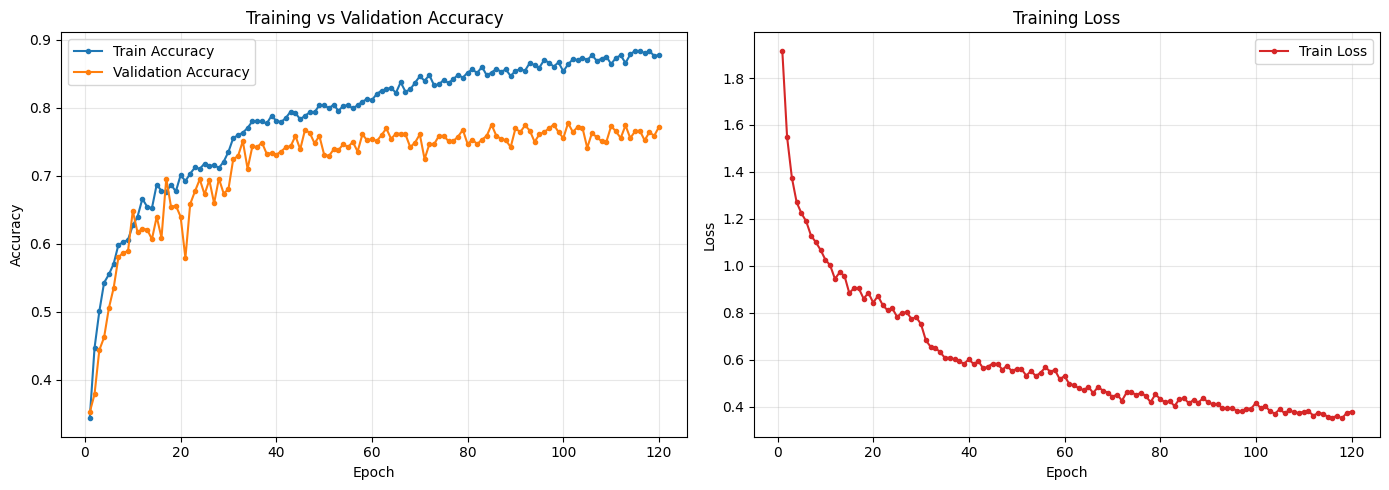

Courbes sauvegardées : /kaggle/working/dgnet_training_output/training_curves.png


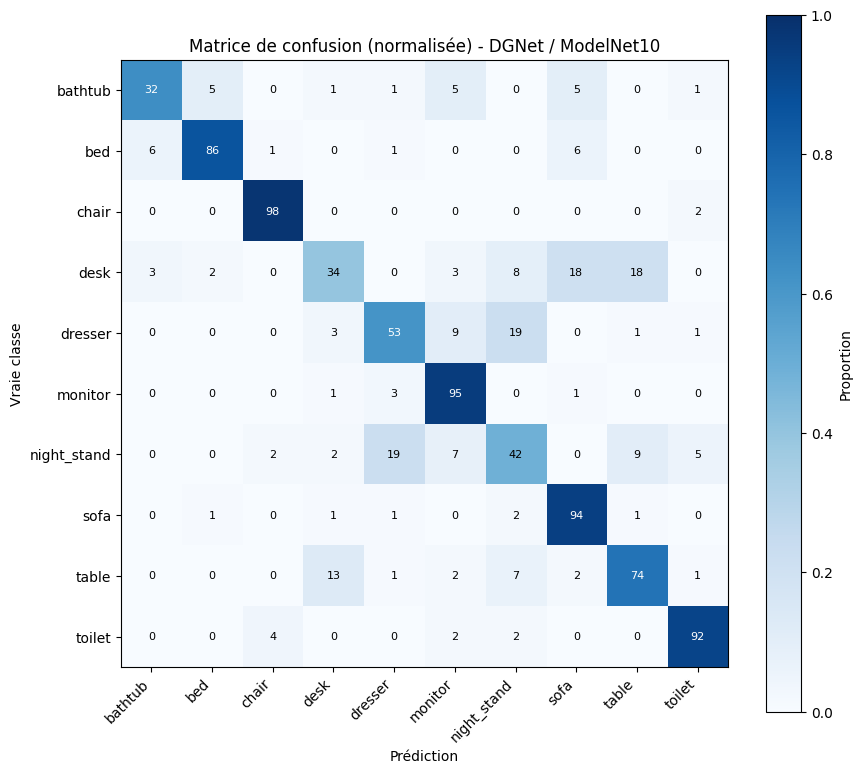

Matrice de confusion sauvegardée : /kaggle/working/dgnet_training_output/confusion_matrix.png

=== Métriques de classification ===
Accuracy          : 0.7709
Precision (macro) : 0.7582
Recall (macro)    : 0.7530
F1-score (macro)  : 0.7501

              precision    recall  f1-score   support

     bathtub       0.78      0.64      0.70        50
         bed       0.91      0.86      0.89       100
       chair       0.93      0.98      0.96       100
        desk       0.62      0.40      0.48        86
     dresser       0.67      0.62      0.64        86
     monitor       0.77      0.95      0.85       100
 night_stand       0.53      0.49      0.51        86
        sofa       0.75      0.94      0.83       100
       table       0.72      0.74      0.73       100
      toilet       0.90      0.92      0.91       100

    accuracy                           0.77       908
   macro avg       0.76      0.75      0.75       908
weighted avg       0.76      0.77      0.76       908



In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, classification_report,
)

CLASS_NAMES = [
    "bathtub", "bed", "chair", "desk", "dresser",
    "monitor", "night_stand", "sofa", "table", "toilet",
]

history_df = pd.read_csv(TRAINING_OUTPUT_DIR / "training_history.csv")

predictions_data = np.load(TRAINING_OUTPUT_DIR / "final_predictions.npz")
y_pred = predictions_data["predictions"]
y_true = predictions_data["labels"]

# --- Courbes Accuracy / Loss ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy", marker="o", markersize=3)
axes[0].plot(history_df["epoch"], history_df["test_acc"], label="Validation Accuracy", marker="o", markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss", marker="o", markersize=3, color="tab:red")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
curves_path = TRAINING_OUTPUT_DIR / "training_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print("Courbes sauvegardées :", curves_path)

# --- Matrice de confusion ---
cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASS_NAMES)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vraie classe")
ax.set_title("Matrice de confusion (normalisée) - DGNet / ModelNet10")

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        text_color = "white" if cm_normalized[i, j] > 0.5 else "black"
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(im, ax=ax, label="Proportion")
plt.tight_layout()
cm_path = TRAINING_OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()
print("Matrice de confusion sauvegardée :", cm_path)

# --- Métriques de classification ---
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

classification_metrics = {
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
}

with open(TRAINING_OUTPUT_DIR / "classification_metrics.json", "w", encoding="utf-8") as f:
    json.dump(classification_metrics, f, indent=2)

print("\n=== Métriques de classification ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (macro) : {precision_macro:.4f}")
print(f"Recall (macro)    : {recall_macro:.4f}")
print(f"F1-score (macro)  : {f1_macro:.4f}")
print("\n" + classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

## 18. Rapport final

In [42]:
with open(TRAINING_OUTPUT_DIR / "training_info.json") as f:
    training_info = json.load(f)
with open(TRAINING_OUTPUT_DIR / "computational_metrics.json") as f:
    computational_metrics = json.load(f)
with open(TRAINING_OUTPUT_DIR / "classification_metrics.json") as f:
    classification_metrics = json.load(f)

per_class_lines = []
for class_index, class_name in enumerate(CLASS_NAMES):
    class_mask = (y_true == class_index)
    class_count = int(class_mask.sum())
    class_correct = int((y_pred[class_mask] == class_index).sum())
    class_acc = class_correct / class_count if class_count > 0 else 0.0
    per_class_lines.append(f"| {class_name} | {class_count} | {class_correct} | {class_acc:.3f} |")

report_content = f"""# Rapport d'expérience — DGNet sur ModelNet10 Original

## 1. Architecture et implémentation

| Champ | Valeur |
|---|---|
| Architecture | DGNet |
| Dépôt officiel | https://github.com/li-xl/DGNet |
| Commit utilisé | 70abf402b58f7d44f0765c0436bfb03b53af4a5d |
| Dataset | ModelNet10 Original |
| Représentation | Mesh (maillage triangulaire) |

### Modifications apportées au code officiel (documentées, cahier des charges §5.1)

1. **Tête de classification** : le dépôt officiel DGNet ne fournit que la segmentation
   sémantique par face (ScanNet, 21 classes). Une tête de classification a été
   construite au-dessus de l'encodeur DGNet (sans décodeur) : pooling global (max)
   sur les faces du niveau le plus grossier, suivi d'une tête FC (`Linear -> ReLU ->
   Dropout -> Linear`) vers 10 classes.
2. **`radius=[None, 0.2, 0.4, 0.8]`** au lieu du défaut officiel `[0., 0.2, 0.4, 0.8]` :
   dans `SpatialConv`, `with_spatial = (radius is not None)`. La valeur `0.` active
   donc à tort la branche spatiale avec une dilatation nulle, produisant un tenseur
   de largeur dégénérée (1) qui fait planter `cudnnConvolutionForward`
   (`CUDNN_STATUS_EXECUTION_FAILED`, reproduit sur GPU T4 et P100). `None` désactive
   correctement la branche, comportement voulu à l'origine.
3. **`SpatialConv.execute` patché** : `conv_sf` (une `Conv2d` dont le noyau couvre
   exactement toute la largeur de son entrée — donc mathématiquement une combinaison
   linéaire, pas une vraie convolution glissante) est remplacée par un `matmul`
   équivalent, contournant un bug cuDNN reproductible sur cette configuration
   GPU/driver Kaggle.
4. **Normalisation des sommets** (centrage + mise à l'échelle dans une sphère unité)
   ajoutée au chargement des maillages : `sample_vbuffer` (regroupement spatial des
   faces voisines) utilise une taille de voxel fixe qui suppose des coordonnées à
   échelle normalisée.
5. **Prétraitement des données** : simplification géométrique par clustering de
   sommets (Open3D `simplify_vertex_clustering`) à 1024 faces cible, au lieu de la
   décimation par effondrement d'arêtes (bloquée sur les maillages non-manifold de
   ModelNet10, voir §2 ci-dessous).

## 2. Prétraitement des données

- Audit complet des 4899 maillages ModelNet10 Original : 0 fichier invalide.
- Diagnostic topologique (NetworkX) : plusieurs classes (desk, night_stand, sofa)
  présentent des centaines de composantes connexes non-watertight (maillages CAO
  non-manifold), qui bloquent la décimation classique.
- Simplification retenue : clustering spatial de sommets (Open3D), atteint la cible
  de 1024 faces (±5%) sur les 10 classes.
- Prétraitement complet des 4899 maillages : 4899/4899 réussis, 0 erreur, 13,1 min.
- Pyramide DGNet à 6 niveaux construite pour chaque maillage.

## 3. Configuration d'entraînement (cahier des charges §9)

| Information | Valeur |
|---|---|
| Nombre d'epochs | {training_info['num_epochs']} |
| Batch size | {training_info['batch_size']} |
| Optimiseur | {training_info['optimizer']} |
| Learning rate initial | {training_info['learning_rate']} |
| Scheduler | {training_info['lr_scheduler']} |
| Weight decay | {training_info['weight_decay']} |
| Loss function | {training_info['loss_function']} |
| Hardware | {training_info['hardware']} ({computational_metrics['gpu_name']}) |
| Seed aléatoire | {training_info['random_seed']} |
| Taille train / test | {training_info['train_size']} / {training_info['test_size']} |
| Durée totale d'entraînement | {training_info['total_training_time_seconds']/60:.1f} min |
| Meilleure epoch | {training_info['best_epoch']} |

## 4. Métriques de classification (cahier des charges §8.1)

| Métrique | Valeur |
|---|---|
| Accuracy | {classification_metrics['accuracy']:.4f} |
| Precision (macro) | {classification_metrics['precision_macro']:.4f} |
| Recall (macro) | {classification_metrics['recall_macro']:.4f} |
| F1-score (macro) | {classification_metrics['f1_macro']:.4f} |
| Precision (pondérée) | {classification_metrics['precision_weighted']:.4f} |
| Recall (pondéré) | {classification_metrics['recall_weighted']:.4f} |
| F1-score (pondéré) | {classification_metrics['f1_weighted']:.4f} |

### Accuracy par classe

| Classe | Nb. échantillons | Corrects | Accuracy |
|---|---|---|---|
{chr(10).join(per_class_lines)}

## 5. Métriques calculatoires (cahier des charges §8.2)

| Métrique | Valeur |
|---|---|
| Nombre de paramètres | {computational_metrics['num_parameters']:,} |
| Temps d'entraînement total | {training_info['total_training_time_seconds']/60:.1f} min |
| Temps moyen / epoch | {training_info['total_training_time_seconds']/training_info['num_epochs']:.1f} s |
| Temps d'inférence (régime stable) | {computational_metrics['avg_inference_time_ms_steady_state']:.2f} ms (± {computational_metrics['std_inference_time_ms_steady_state']:.2f} ms) |
| Mémoire GPU utilisée | {computational_metrics['gpu_memory_used_mb']:.0f} / {computational_metrics['gpu_memory_total_mb']:.0f} Mo |
| GPU | {computational_metrics['gpu_name']} |

## 6. Visualisations (cahier des charges §10.1)

- Courbes Training/Validation Accuracy et Training Loss : `training_curves.png`
- Matrice de confusion normalisée : `confusion_matrix.png`

## 7. Reproductibilité (cahier des charges §5.3)

- Seed aléatoire : {training_info['random_seed']} (numpy + jittor)
- Checkpoints sauvegardés : `checkpoints/best_model.pkl`, `checkpoints/final_model.pkl`,
  et un checkpoint tous les 5 epochs
- Historique complet epoch par epoch : `training_history.csv`
- Prédictions finales (test) : `final_predictions.npz`
"""

report_path = TRAINING_OUTPUT_DIR / "RAPPORT_DGNet_ModelNet10.md"
report_path.write_text(report_content, encoding="utf-8")
print("Rapport écrit :", report_path)
print(f"\nTaille du rapport : {len(report_content)} caractères")

Rapport écrit : /kaggle/working/dgnet_training_output/RAPPORT_DGNet_ModelNet10.md

Taille du rapport : 4830 caractères
